# Kunci Jawaban - Linear Regression

- **Dataset:** [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance)
- **Target:** `G3`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [ ]:
%pip install ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan line plot.
- `seaborn`: membuat visualisasi statistik seperti count plot, bar plot, dan boxplot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Student Performance menggunakan ID dataset dari UCI.

In [5]:
student_performance = fetch_ucirepo(id=320)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [6]:
X_raw = student_performance.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [7]:
y_raw = student_performance.data.targets.copy()

### Tentukan kolom target

Simpan nama kolom target ke variabel `TARGET_COL` agar mudah dipakai ulang di bagian berikutnya.

In [8]:
TARGET_COL = "G3"

### Gabungkan fitur dan target

Gabungkan fitur dan satu target yang dipilih menjadi satu DataFrame bernama `df`.

In [9]:
df = pd.concat([X_raw, y_raw[[TARGET_COL]]], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom dataset.

In [10]:
df.shape

(649, 31)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki **649 baris** dan **31 kolom**.

> Berapa jumlah fitur dan targetnya?

Jawaban: Dataset memiliki **30 fitur** dan **1 target** yang dipakai, yaitu `G3`.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat bentuk data.

In [11]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,13


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Tidak, dataset memiliki campuran kolom numerik dan kategori.

> Apakah dataset membutuhkan encoding kategori sebelum modeling?

Jawaban: Ya, kolom kategori perlu diubah menjadi numerik menggunakan one-hot encoding.

## 3 - Data Understanding

### Tampilkan informasi dataset

Gunakan `info()` untuk melihat tipe data dan jumlah data non-null.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Dataset memiliki **17 kolom object** dan **14 kolom int64**.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak, semua kolom memiliki jumlah non-null yang sama dengan jumlah baris dataset, yaitu **649 non-null**.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [13]:
df.isna().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G3            0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value. Semua kolom memiliki missing value **0**.

> Apakah data perlu diisi menggunakan mean, median, atau metode imputasi lain?

Jawaban: Tidak perlu, karena dataset tidak memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris yang duplikat penuh.

In [14]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah **0**.

> Apa keputusan cleaning yang perlu dilakukan?

Jawaban: Tidak ada baris duplikat yang perlu dihapus.

### Tampilkan statistik deskriptif

Gunakan `describe()` untuk melihat ringkasan nilai numerik pada dataset.

In [15]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G3
count,649.000,649.000,649.000,649.000,649.000,649.000,649.000,649.000,649.000,649.000,649.000,649.000,649.000,649.000
mean,16.744,2.515,2.307,1.569,1.931,0.222,3.931,3.180,3.185,1.502,2.280,3.536,3.659,11.906
std,1.218,1.135,1.100,0.749,0.830,0.593,0.956,1.051,1.176,0.925,1.284,1.446,4.641,3.231
min,15.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000
25%,16.000,2.000,1.000,1.000,1.000,0.000,4.000,3.000,2.000,1.000,1.000,2.000,0.000,10.000
50%,17.000,2.000,2.000,1.000,2.000,0.000,4.000,3.000,3.000,1.000,2.000,4.000,2.000,12.000
75%,18.000,4.000,3.000,2.000,2.000,0.000,5.000,4.000,4.000,2.000,3.000,5.000,6.000,14.000
max,22.000,4.000,4.000,4.000,4.000,3.000,5.000,5.000,5.000,5.000,5.000,5.000,32.000,19.000


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar fitur?

Jawaban: Skala fitur numerik berbeda. Contohnya, `absences` dapat bernilai puluhan, sedangkan banyak fitur lain berupa skor kecil seperti 1 sampai 5.

> Mengapa scaling diperlukan sebelum model dilatih?

Jawaban: Scaling diperlukan agar perbedaan satuan dan skala antar fitur tidak terlalu memengaruhi proses modeling.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh dari dataset.

In [16]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index agar nomor baris kembali rapi setelah cleaning.

In [17]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah cleaning.

In [18]:
df_clean.shape

(649, 31)

> Berdasarkan output, berapa ukuran dataset setelah cleaning?

Jawaban: Setelah cleaning, dataset tetap memiliki **649 baris** dan **31 kolom**.

> Berapa jumlah baris yang berkurang dari dataset awal?

Jawaban: Tidak ada baris yang berkurang karena tidak ditemukan duplikat penuh.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat yang tersisa.

In [19]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak, jumlah duplikat setelah cleaning adalah **0**.

> Jelaskan kondisi dataset setelah duplikat dihapus.

Jawaban: Dataset sudah bersih dari duplikat penuh dan siap digunakan untuk EDA serta modeling.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Lihat ringkasan statistik kolom target.

In [20]:
df_clean[TARGET_COL].describe()

count   649.000
mean     11.906
std       3.231
min       0.000
25%      10.000
50%      12.000
75%      14.000
max      19.000
Name: G3, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Target memiliki mean sekitar **11.91**, nilai minimum **0**, dan nilai maksimum **19**.

> Apa yang bisa disimpulkan dari rentang nilai target tersebut?

Jawaban: `G3` adalah nilai akhir siswa dengan rentang skor terbatas, sehingga target berupa skor numerik diskret.

### Buat count plot target

Gunakan count plot karena target `G3` berupa skor diskret.

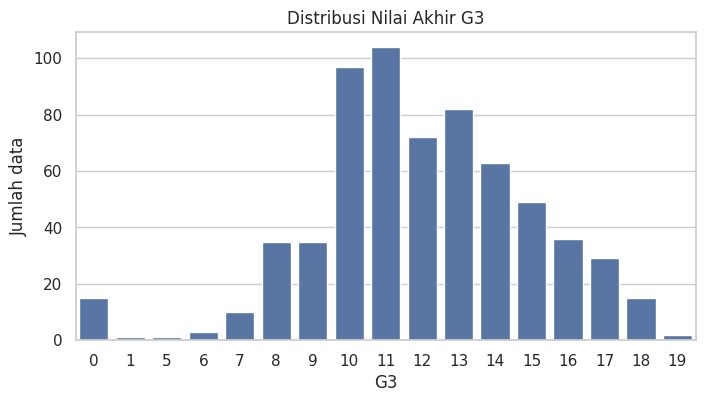

In [21]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x=TARGET_COL)
plt.title("Distribusi Nilai Akhir G3")
plt.xlabel("G3")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan count plot, skor G3 mana yang paling banyak muncul?

Jawaban: Skor G3 paling banyak muncul di area sekitar **10 sampai 14**.

> Mengapa count plot lebih tepat daripada scatter plot untuk target ini?

Jawaban: Count plot lebih tepat karena `G3` berupa skor diskret, sehingga jumlah data per skor lebih mudah dibaca.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target.

In [22]:
numeric_corr = df_clean.select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

studytime     0.250
Medu          0.240
Fedu          0.212
famrel        0.063
goout        -0.088
absences     -0.091
health       -0.099
age          -0.107
freetime     -0.123
traveltime   -0.127
Walc         -0.177
Dalc         -0.205
failures     -0.393
Name: G3, dtype: float64

> Berdasarkan output korelasi, fitur numerik apa saja yang memiliki korelasi positif paling terlihat terhadap target?

Jawaban: `studytime`, `Medu`, dan `Fedu` memiliki korelasi positif paling terlihat terhadap target.

> Fitur numerik apa yang memiliki korelasi negatif terhadap target?

Jawaban: `failures`, `Dalc`, dan `Walc` memiliki korelasi negatif terhadap target. Korelasi negatif paling besar terlihat pada `failures`.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat korelasi fitur numerik dengan target secara visual.

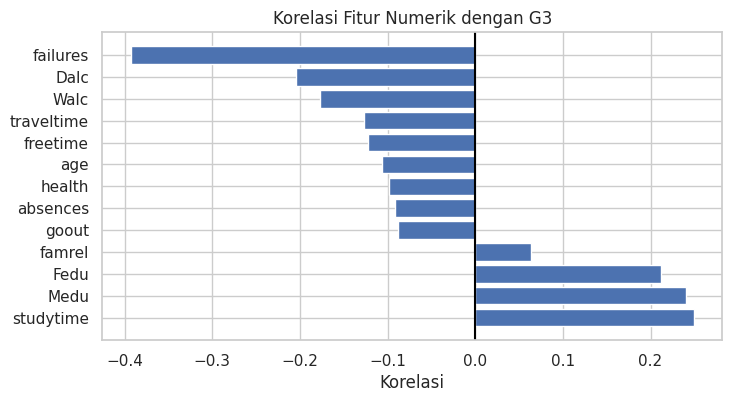

In [23]:
plt.figure(figsize=(8, 4))
plt.barh(numeric_corr.index, numeric_corr.values)
plt.axvline(0, color="black")
plt.title("Korelasi Fitur Numerik dengan G3")
plt.xlabel("Korelasi")
plt.show()

> Berdasarkan bar plot, fitur mana yang berada pada sisi korelasi positif dan sisi korelasi negatif?

Jawaban: Sisi positif berisi `studytime`, `Medu`, `Fedu`, dan `famrel`. Sisi negatif berisi `failures`, `Dalc`, `Walc`, dan beberapa fitur lain.

> Apa arti arah korelasi tersebut terhadap target?

Jawaban: Korelasi positif berarti nilai fitur cenderung naik bersama G3, sedangkan korelasi negatif berarti nilai fitur cenderung naik ketika G3 menurun.

### Buat bar plot rata-rata G3 berdasarkan Studytime

Gunakan bar plot rata-rata karena `studytime` berupa kelompok skor.

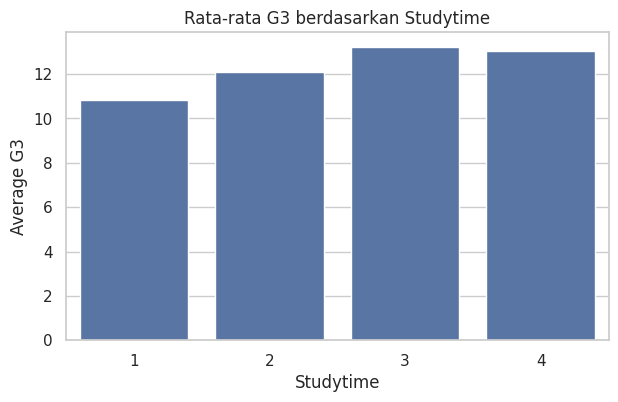

In [24]:
studytime_mean = df_clean.groupby("studytime")[TARGET_COL].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=studytime_mean, x="studytime", y=TARGET_COL)
plt.title("Rata-rata G3 berdasarkan Studytime")
plt.xlabel("Studytime")
plt.ylabel("Average G3")
plt.show()

> Berdasarkan bar plot, bagaimana rata-rata G3 pada tingkat studytime yang berbeda?

Jawaban: Rata-rata G3 cenderung lebih tinggi pada studytime yang lebih besar.

> Mengapa bar plot rata-rata lebih tepat untuk fitur ini?

Jawaban: Bar plot rata-rata lebih tepat karena `studytime` berupa kelompok skor, bukan fitur kontinu murni.

### Buat bar plot rata-rata G3 berdasarkan Failures

Gunakan bar plot rata-rata untuk melihat hubungan jumlah kegagalan sebelumnya dengan nilai akhir.

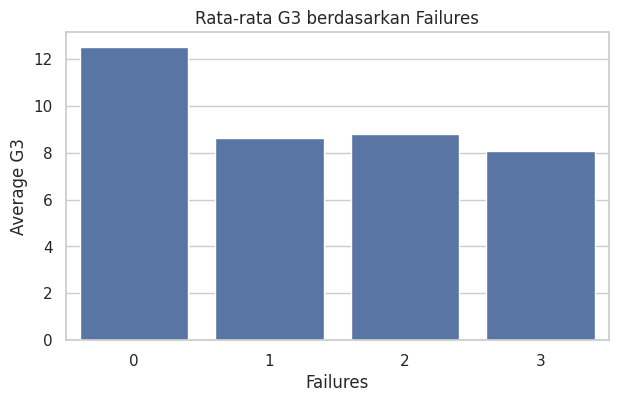

In [25]:
failures_mean = df_clean.groupby("failures")[TARGET_COL].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=failures_mean, x="failures", y=TARGET_COL)
plt.title("Rata-rata G3 berdasarkan Failures")
plt.xlabel("Failures")
plt.ylabel("Average G3")
plt.show()

> Berdasarkan bar plot, bagaimana rata-rata G3 pada jumlah failures yang berbeda?

Jawaban: Rata-rata G3 cenderung lebih rendah ketika jumlah `failures` lebih tinggi.

> Apa arti pola tersebut terhadap target?

Jawaban: Pola tersebut menunjukkan hubungan negatif antara `failures` dan G3.

## 6 - Feature dan Target

### Pisahkan fitur awal

Simpan semua kolom selain target ke variabel `X_raw_model`.

In [26]:
X_raw_model = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke variabel `y`.

In [27]:
y = df_clean[TARGET_COL]

### Encode fitur kategori

Ubah kolom kategori menjadi numerik menggunakan one-hot encoding.

In [28]:
X = pd.get_dummies(X_raw_model, drop_first=True)

### Tampilkan ukuran fitur setelah encoding

Cek ukuran `X` setelah fitur kategori di-encode.

In [29]:
X.shape

(649, 39)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X` setelah encoding?

Jawaban: `X` memiliki **649 baris** dan **39 fitur** setelah encoding.

### Tampilkan ukuran target

Cek ukuran `y` setelah target dipisahkan.

In [30]:
y.shape

(649,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki **649 nilai target**.

> Apakah jumlah baris `X` dan `y` sudah sama?

Jawaban: Ya, jumlah baris `X` dan `y` sudah sama, yaitu **649**.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [31]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji yang digunakan adalah **20%**, sedangkan data latih adalah **80%** dari seluruh dataset.

### Bagi data train dan test

Bagi data menjadi data train dan test.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Cek jumlah data dan fitur pada `X_train`.

In [33]:
X_train.shape

(519, 39)

### Tampilkan ukuran X_test

Cek jumlah data dan fitur pada `X_test`.

In [34]:
X_test.shape

(130, 39)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki **519 baris**, sedangkan data test memiliki **130 baris**.

> Apakah jumlah fitur pada train dan test tetap sama?

Jawaban: Ya, jumlah fitur pada train dan test tetap sama, yaitu **39 fitur**.

## 8 - Feature Scaling

### Buat object scaler

Gunakan `StandardScaler` untuk menstandarkan fitur.

In [35]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler hanya pada data train, lalu transform data train.

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Transform data test menggunakan scaler yang sudah di-fit pada data train.

In [37]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [38]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [39]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan untuk prediksi?

Jawaban: Output `LinearRegression()` menunjukkan bahwa object model sudah berhasil dilatih dan siap digunakan untuk prediksi.

### Tampilkan intercept model

Tampilkan nilai intercept dari model.

In [40]:
model.intercept_

np.float64(11.79383429672447)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar **11.79**.

> Apa makna intercept setelah seluruh fitur di-scale?

Jawaban: Intercept adalah nilai dasar prediksi ketika seluruh fitur berada pada titik nol setelah scaling.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel sederhana.

In [41]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_table.sort_values("Coefficient", ascending=False).head(10)

,Feature,Coefficient
36,higher_yes,0.527
4,studytime,0.300
2,Fedu,0.283
18,Mjob_health,0.259
20,Mjob_services,0.190
21,Mjob_teacher,0.165
6,famrel,0.162
0,age,0.134
15,address_U,0.132
30,guardian_other,0.132


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Koefisien positif terbesar yang terlihat adalah `higher_yes` sekitar **0.53**.

> Apa arti koefisien positif pada tabel?

Jawaban: Koefisien positif berarti fitur cenderung menaikkan prediksi G3.

### Tampilkan koefisien negatif terbesar

Tampilkan fitur dengan koefisien paling negatif.

In [42]:
coef_table.sort_values("Coefficient", ascending=True).head(10)

,Feature,Coefficient
5,failures,-0.884
13,school_MS,-0.666
24,Fjob_services,-0.498
31,schoolsup_yes,-0.486
11,health,-0.328
9,Dalc,-0.242
23,Fjob_other,-0.239
12,absences,-0.238
14,sex_M,-0.237
27,reason_other,-0.220


> Berdasarkan tabel koefisien negatif, fitur mana yang memiliki koefisien negatif terbesar?

Jawaban: Koefisien negatif terbesar adalah `failures` sekitar **-0.88**.

> Apa arti koefisien negatif pada tabel?

Jawaban: Koefisien negatif berarti fitur cenderung menurunkan prediksi G3.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk memprediksi data train.

In [43]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk memprediksi data test.

In [44]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama dari data test.

In [45]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_test_pred[:5]
})
prediction_preview

,Actual,Predicted
0,19,13.073
1,12,12.969
2,18,14.019
3,11,12.004
4,11,10.364


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dan paling jauh dari nilai aktual?

Jawaban: Prediksi paling dekat terlihat pada baris ke-4, dengan aktual **11** dan prediksi **12.00**. Prediksi paling jauh terlihat pada baris ke-1, dengan aktual **19** dan prediksi **13.07**.

> Apa yang bisa disimpulkan dari selisih aktual dan prediksi?

Jawaban: Beberapa prediksi cukup dekat, tetapi ada prediksi yang meleset cukup jauh dari nilai aktual.

### Hitung MAE train

Hitung rata-rata error absolut pada data train.

In [46]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

1.8320200414713534

### Hitung MAE test

Hitung rata-rata error absolut pada data test.

In [47]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

2.156382187028527

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar **2.16**.

> Apa arti rata-rata error absolut tersebut?

Jawaban: Artinya, rata-rata prediksi model meleset sekitar **2.16 poin G3** dari nilai aktual.

### Hitung RMSE train

Hitung RMSE pada data train.

In [48]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(2.539221857416282)

### Hitung RMSE test

Hitung RMSE pada data test.

In [49]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(2.8617799377344206)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar **2.86**.

> Mengapa nilai RMSE dapat lebih besar daripada MAE?

Jawaban: RMSE dapat lebih besar daripada MAE karena RMSE memberi penalti lebih besar pada error yang besar.

### Hitung R2 train

Hitung R2 Score pada data train.

In [50]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.38744907311128973

### Hitung R2 test

Hitung R2 Score pada data test.

In [51]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.16016991964318295

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar **0.16**.

> Berapa persen variasi target pada data test yang dapat dijelaskan oleh model?

Jawaban: Model dapat menjelaskan sekitar **16%** variasi G3 pada data test.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 ke dalam satu tabel ringkas.

In [52]:
evaluation_table = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})
evaluation_table

,Subset,MAE,RMSE,R2
0,Train,1.832,2.539,0.387
1,Test,2.156,2.862,0.160


> Berdasarkan tabel evaluasi, bandingkan MAE, RMSE, dan R2 pada data train dan data test.

Jawaban: MAE test lebih besar daripada MAE train, RMSE test lebih besar daripada RMSE train, dan R2 test lebih kecil daripada R2 train.

> Berapa persen perbedaannya, dan apa makna perbandingan tersebut?

Jawaban: MAE test sekitar **17.71%** lebih besar, RMSE test sekitar **12.70%** lebih besar, dan R2 test sekitar **58.66%** lebih kecil dibanding train. Performa test terlihat lebih lemah daripada train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk melihat kedekatan nilai aktual dan prediksi pada data test.

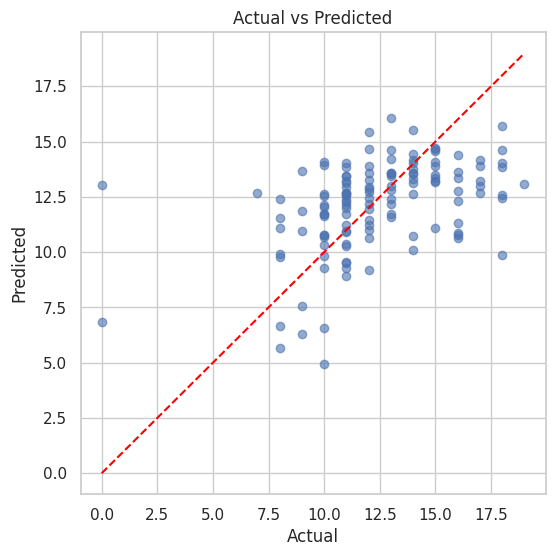

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 11 - Kesimpulan

Dataset Student Performance digunakan untuk memprediksi `G3` atau nilai akhir siswa berdasarkan data akademik, keluarga, dan aktivitas siswa. Data tidak memiliki missing value dan tidak memiliki baris duplikat penuh. Setelah cleaning, dataset memiliki **649** baris dan **31** kolom.

Hasil EDA menunjukkan bahwa `studytime`, `Medu`, dan `Fedu` memiliki hubungan positif dengan target, sedangkan `failures`, `Dalc`, dan `Walc` cenderung memiliki hubungan negatif. Kolom kategori diubah menjadi numerik menggunakan `pd.get_dummies()`. Data dibagi menjadi **80%** data train dan **20%** data test, lalu fitur di-scale menggunakan `StandardScaler`.

Model Linear Regression menghasilkan MAE test sekitar **2.16**, RMSE test sekitar **2.86**, dan R2 test sekitar **0.16**. Berdasarkan metrik tersebut, model mampu menjelaskan sekitar **16%** variasi target pada data test dengan rata-rata error absolut sekitar **2.16 poin G3**.